<center><img src="img/logo_hse.png" width="1000"></center>

<h1><center>Генеративные модели в машинном обучении, МОВС, ФКН ВШЭ</center></h1>
<h2><center>Домашнее задание 3: Диффузия, потоки</center></h2>

# Введение

До заголовка "Диффузионные модели" все по-старому. Только Задания 1-2 теперь неоцениваемые, ведь вы их уже делали

## MAGIC – Major Atmospheric Gamma Imaging Cherenkov Telescope

MAGIC (Major Atmospheric Gamma Imaging Cherenkov) - это система, состоящая из двух черенковских телескопов диаметром 17 м. Они предназначены для наблюдения гамма-лучей от галактических и внегалактических источников в диапазоне очень высоких энергий (от 30 ГэВ до 100 ТэВ).

MAGIC позволил открыть и исследовать новые классы источников гамма-излучения, таких как, например, пульсары и гамма-всплески (GRB).

<center><img src="img/magic1.jpg" width="1000"></center>

Источник: https://magic.mpp.mpg.de/

Youtube video: https://youtu.be/mjcDSR2vSU8

    Ок, давайте зафиксируем. Какой-то крутой телескоп позволяет открыть новые виды излучения. Идем дальше.

## Частицы из космоса

Космические частицы, $\gamma$-кванты (фотоны) и адроны (протоны), взаимодействуют с атмосферой и порождают ливни вторичных частиц. Двигаясь с околосветовой скоростью, эти частицы излучают Черенковское излучение. Телескопы фотографируют это излучение.

    По фотографиям можно определить тип частицы из космоса: фотон или протон. Знакомая формулировка задачи, не правда ли?

<center><img src="img/shower.jpg" width="500"></center>

## Фотографии

Задача атмосферного черенковского телескопа - получить изображение ливня путем измерения черенковского света от частиц ливня. Это изображение представляет собой геометрическую проекцию ливня на детектор. Для анализа этих изображений были введены параметры изображения или так называемые параметры Хилласа. Ниже пример такой фотографии.

<center><img src="img/geo.jpg" width="400"></center>

    Итак, каждая фотография описывается набором параметров, которые за нас считает телесоп. А что там с двумя видами частиц?

## Фотоны vs адронов

Изображения для $\gamma$-квантов (фотонов) и адронов (протонов) отличаются по форме кластеров. Астрономы используют модели машинного обучения для классификации этих изображений. Получение каждого такого изображения - дорогое удовольствие!


<center><img src="img/gamma_p.png" width="600"></center>

Для обучения моделей ученые искусственно генерируют такие изображения для каждого типа частиц с помощью сложных физических симуляторов.

    Итак, давайте сэкономим денег для ученых и сгенерируем хороших фотографий разных частиц. Используем для этого GAN и диффузионные модели!

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Данные

Будем использовать данные телескопа MAGIC из UCI репозитория https://archive.ics.uci.edu/ml/datasets/MAGIC+Gamma+Telescope. Каждый объект в данных - параметры одного изображения кластера и метка этого кластера (фотон или адрон):


0. Length: major axis of ellipse [mm]
1. Width: minor axis of ellipse [mm]
2. Size: 10-log of sum of content of all pixels [in #phot]
3. Conc: ratio of sum of two highest pixels over fSize [ratio]
4. Conc1: ratio of highest pixel over fSize [ratio]
5. Asym: distance from highest pixel to center, projected onto major axis [mm]
6. M3Long: 3rd root of third moment along major axis [mm]
7. M3Trans: 3rd root of third moment along minor axis [mm]
8. Alpha: angle of major axis with vector to origin [deg]
9. Dist: distance from origin to center of ellipse [mm]
10. class: g,h # gamma (signal), hadron (background)

In [2]:
# read data
names = np.array(
    [
        "Length",
        "Width",
        "Size",
        "Conc",
        "Conc1",
        "Asym",
        "M3Long",
        "M3Trans",
        "Alpha",
        "Dist",
        "class",
    ]
)
data = pd.read_csv("data/magic04.data", header=None)
data.columns = names
print(data.shape)
data.head()

(19020, 11)


,Length,Width,Size,Conc,Conc1,Asym,M3Long,M3Trans,Alpha,Dist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


# Постановка задачи

Ваша задача заключается в том, чтобы с помощью генеративно-состязательных сетей научиться генерировать параметры кластеров на изображениях телескопа для каждого типа частиц (фотона или адрона):

- $X$ - матрица реальных объектов, которые нужно начиться генерировать;
- $y$ - метки классов, которые будем использовать как условие при генерации.

In [3]:
# параметры кластеров на изображениях
X = data[names[:-1]].values
X = np.abs(X)

# метки классов
labels = data[names[-1]].values
y = np.ones((len(labels), 1))
y[labels == "h"] = 0

In [4]:
# примеры
X[:2]

array([[2.87967e+01, 1.60021e+01, 2.64490e+00, 3.91800e-01, 1.98200e-01,
        2.77004e+01, 2.20110e+01, 8.20270e+00, 4.00920e+01, 8.18828e+01],
       [3.16036e+01, 1.17235e+01, 2.51850e+00, 5.30300e-01, 3.77300e-01,
        2.62722e+01, 2.38238e+01, 9.95740e+00, 6.36090e+00, 2.05261e+02]])

In [5]:
# примеры
y[:10]

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

In [6]:
# все возможные значения
np.unique(y)

array([0., 1.])

# Визуализация данных

Каждое изображение описывается 10 параметрами. Давайте построим распределения значений каждого параметра для каждого типа частиц.

In [7]:
def plot_hists(X1, X2, names, label1, label2, bins=np.linspace(-3, 3, 61)):
    plt.figure(figsize=(5 * 4, 5 * 2))
    for i in range(X1.shape[1]):
        plt.subplot(3, 4, i + 1)
        plt.grid()
        plt.hist(X1[:, i], bins=bins, alpha=0.3, label=label1, color="C4")
        plt.hist(X2[:, i], bins=bins, alpha=0.3, label=label2, color="C0")
        plt.xlabel(names[i], size=14)
        plt.legend(loc="best")
    plt.tight_layout()

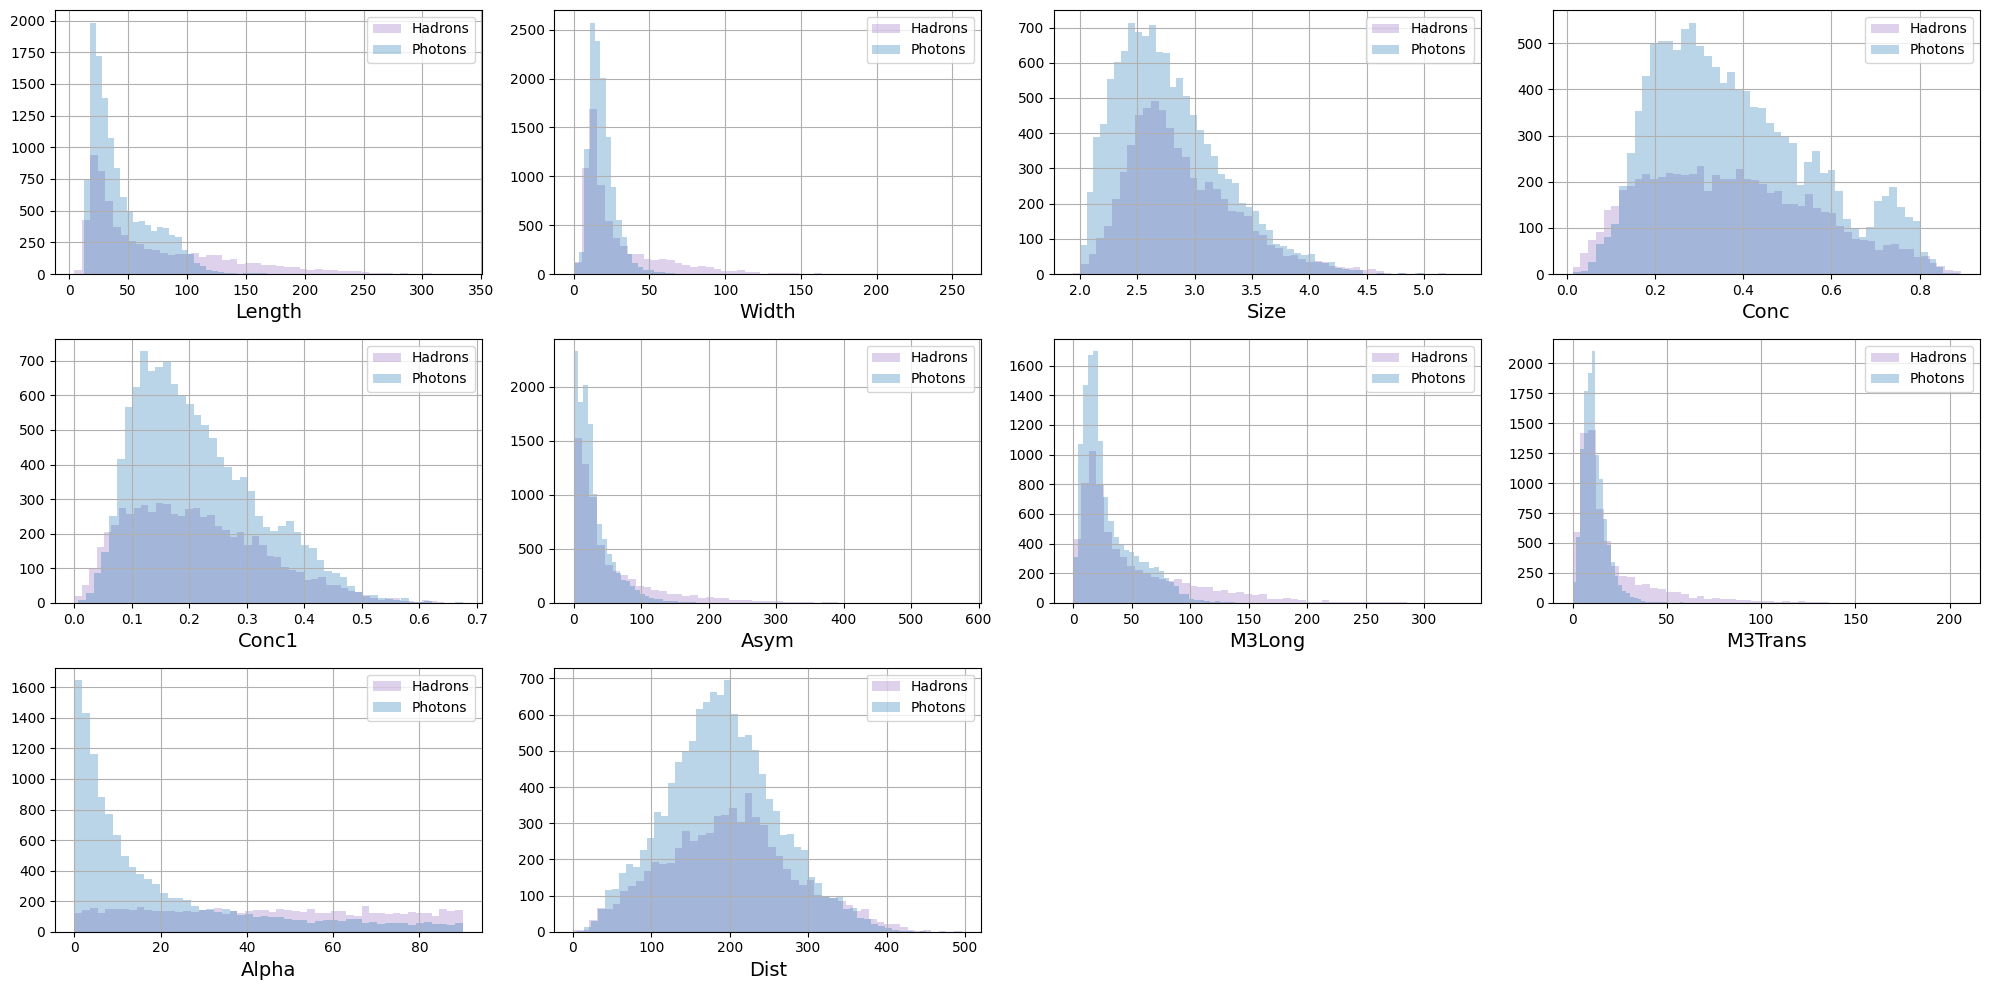

In [8]:
plot_hists(
    X[y[:, 0] == 0], X[y[:, 0] == 1], names, label1="Hadrons", label2="Photons", bins=50
)

# Предобработка данных

Из графика видим, что распределения для многих признаков имеют тяжелые хвосты. Это делает обучение генеративных моделей тяжелее. Поэтому нужно как-то преобразовать данные, чтобы убрать эти тяжелые хвосты.

# Обучающая и тестовая выборки

In [311]:
from sklearn.model_selection import train_test_split

# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify = y, test_size=0.5, shuffle = True, random_state = 11
)

## Задание 1 (0 баллов)

Проиллюстрируйте распределение y внутри train и test выборки.

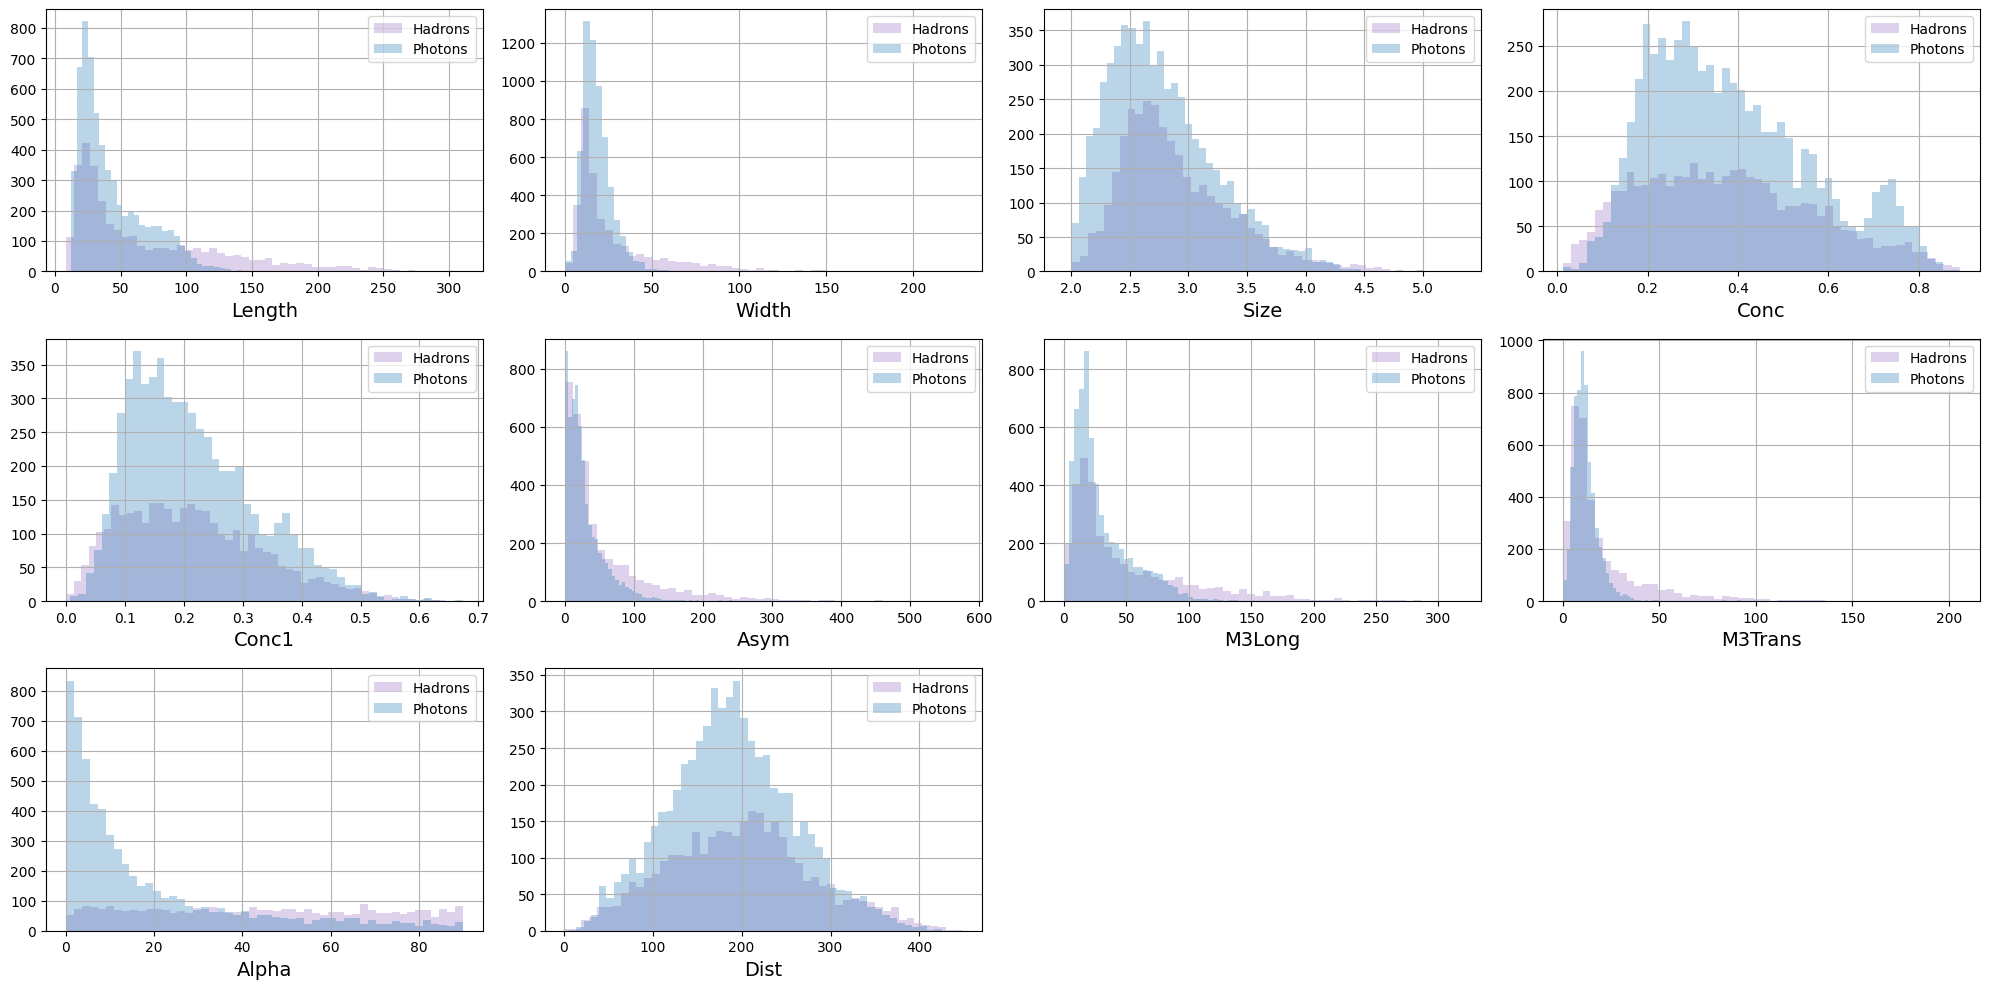

In [312]:
# your code be low
plot_hists(
X_train[y_train[:, 0] == 0], X_train[y_train[:, 0] == 1], names, label1="Hadrons", label2="Photons", bins=50
)


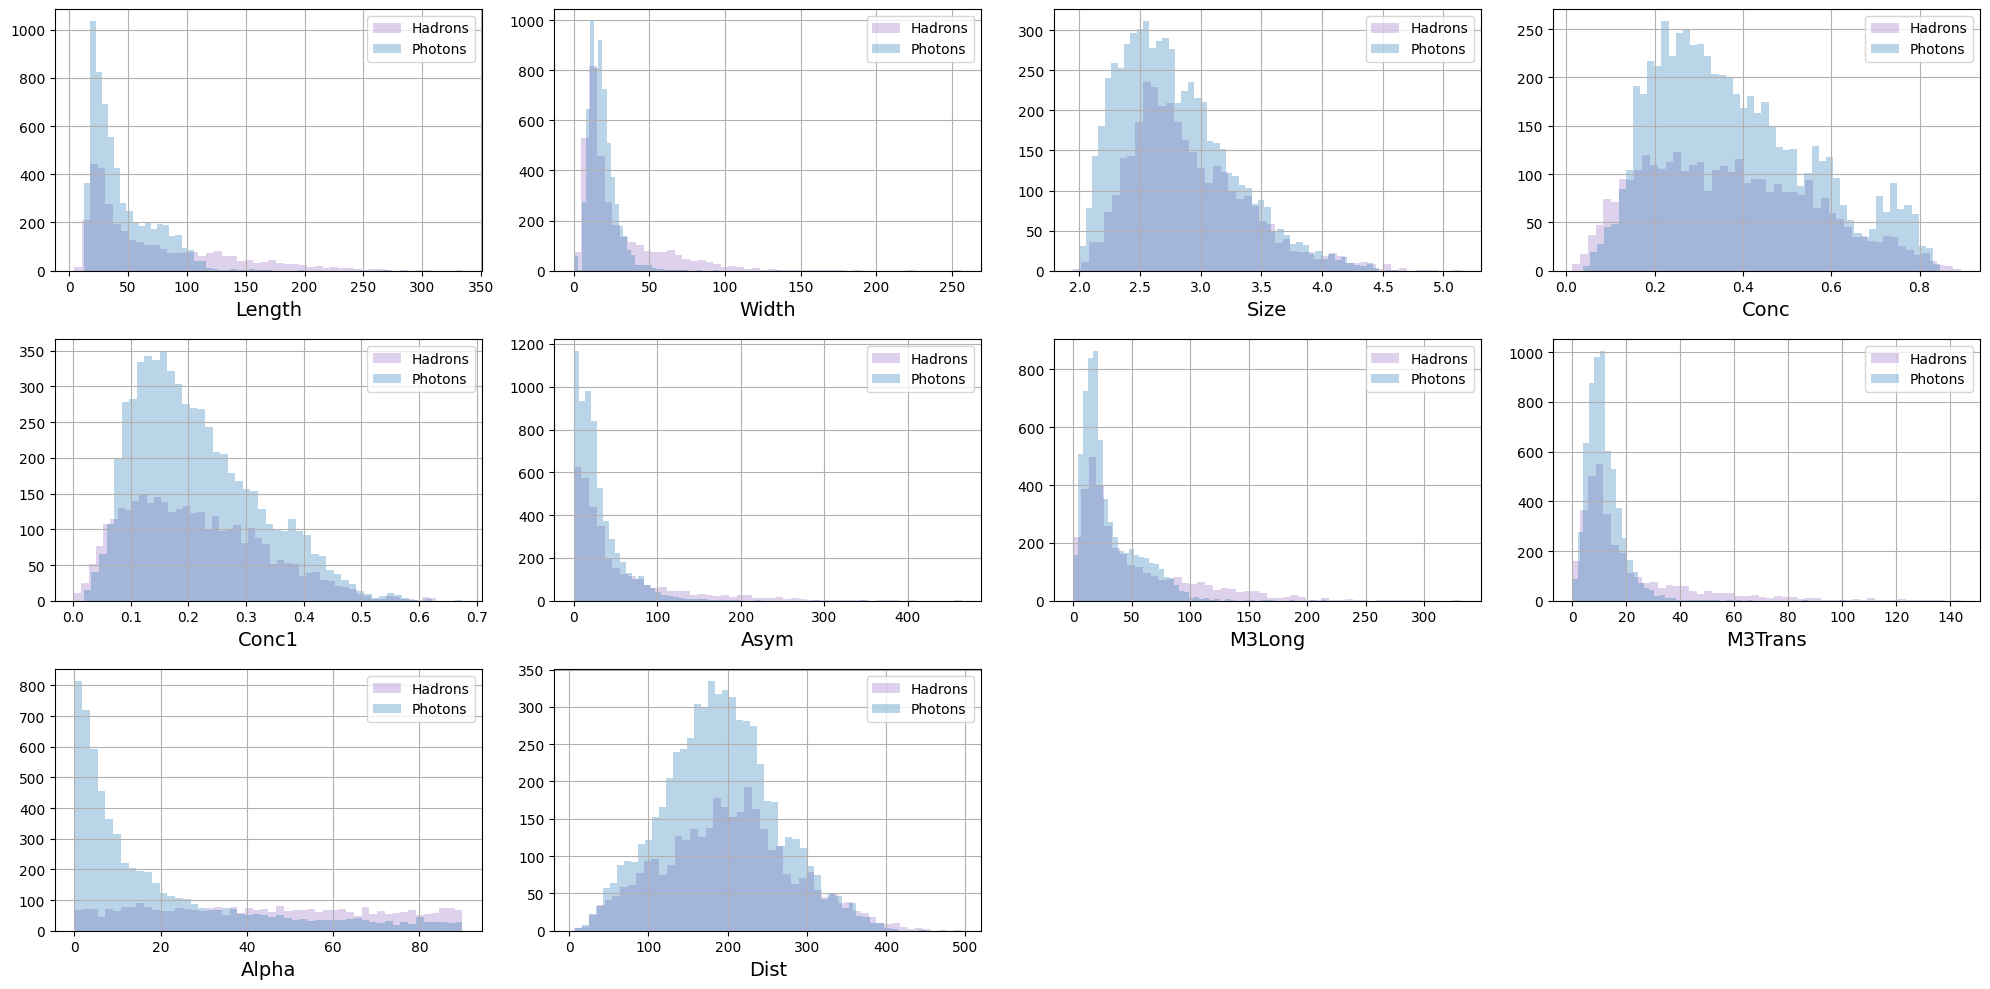

In [313]:
plot_hists(
X_test[y_test[:, 0] == 0], X_test[y_test[:, 0] == 1], names, label1="Hadrons", label2="Photons", bins=50
)

## Задание 2 (0 баллов)

Используя функцию `sklearn.preprocessing.QuantileTransformer` трансформируйте входные данные `X_train` и `X_test`. Это преобразование делает так, чтобы распределение каждого параметра было нормальным. Описание функции доступно по [ссылке](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.QuantileTransformer.html). Используйте значение параметра `output_distribution='normal'`.

In [314]:
from sklearn.preprocessing import QuantileTransformer
qt = QuantileTransformer(n_quantiles=500, random_state=42,output_distribution='normal')


In [360]:
### YOUR CODE IS HERE ######
X_train_qt = qt.fit_transform(X_train)
X_test_qt =  qt.transform(X_test)  
### THE END OF YOUR CODE ###

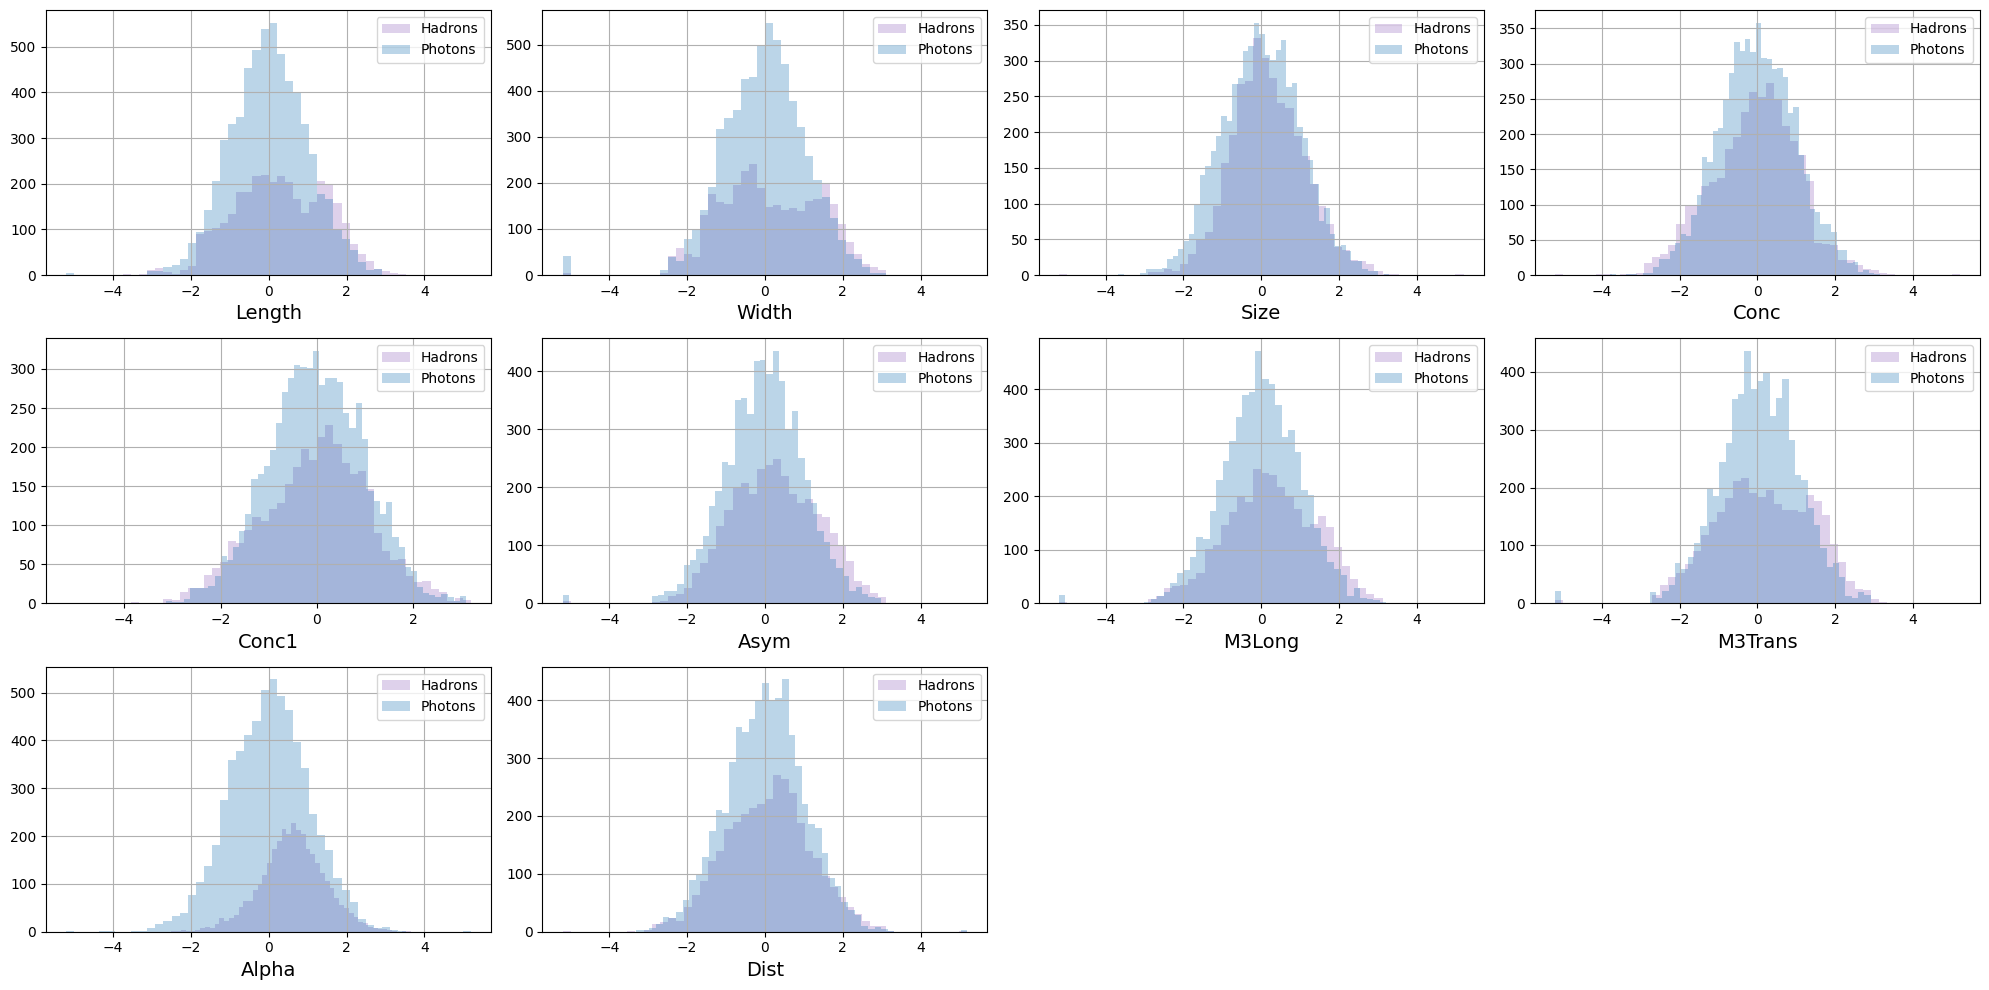

In [494]:
plot_hists(
    X_train_qt[y_train[:, 0] == 0],
    X_test_qt[y_train[:, 0] == 1],
    names,
    label1="Hadrons",
    label2="Photons",
    bins=50,
)

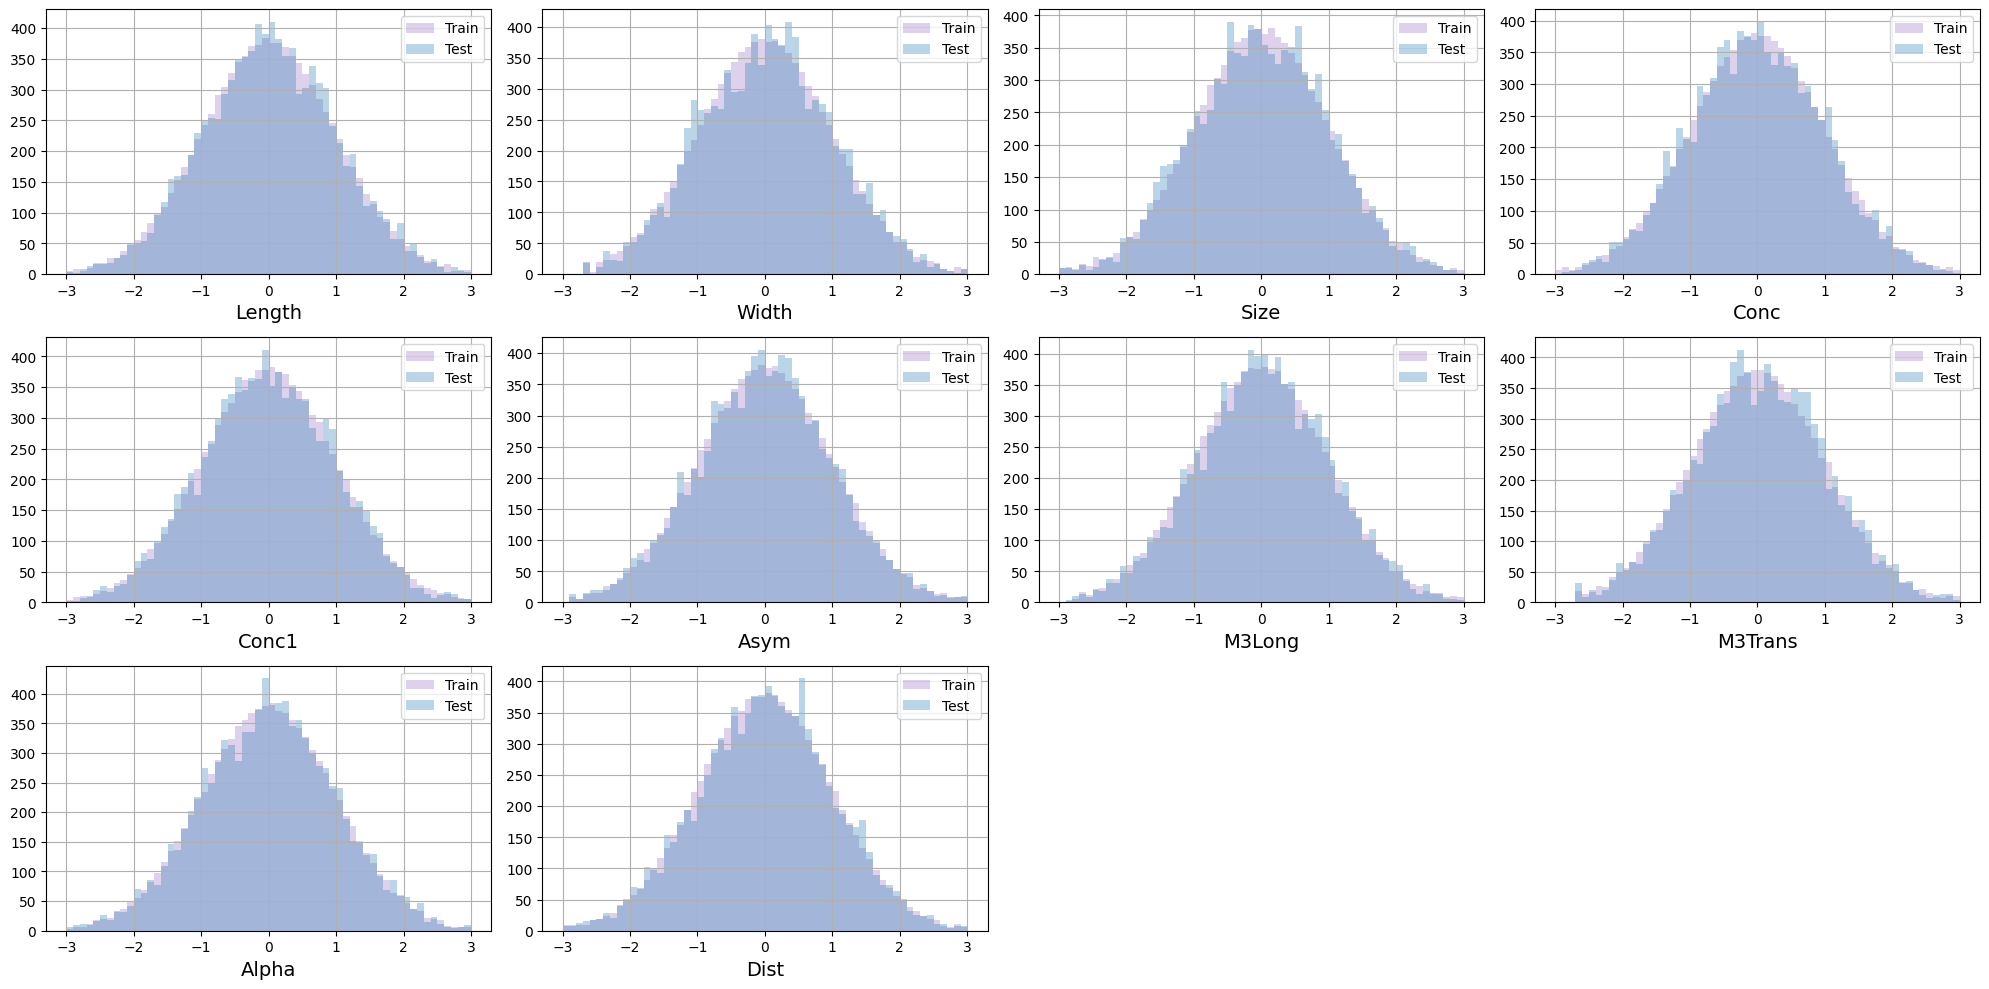

In [495]:
plot_hists(X_train_qt, X_test_qt, names, label1="Train", label2="Test")

# Диффузионные модели (4 балла)

Проведем, по большому счету, такой же эксперимент, как в ДЗ-2, с диффузионной моделью.

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Задание 3 (0.5 балла)

Реализуйте фукнцию из семинара для зашумления данных, адаптировав ее под наш тип данных.

In [25]:
from IPython.display import display
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 1000)

In [27]:
np.set_printoptions(threshold=1000, edgeitems=10, linewidth=1000)

In [318]:
X_test_qt

array([[-0.1306996 , -1.9923271 , -0.39072476,  0.39142386,  0.18054423,  0.98436704,  0.18753031, -1.18413185, -0.52777614,  0.80741134],
       [ 2.23343306,  1.90266361,  2.61585222, -2.37668507, -2.32153091,  1.020457  ,  2.18047339,  1.04644207,  1.43150852,  1.91098262],
       [-1.90358561, -0.95483073, -1.23337773,  2.05836288,  1.84978885, -0.46337954, -2.11599468,  0.08549839,  0.11869917,  0.00702716],
       [-1.22231348, -1.43246586, -1.11108197,  1.37381013,  1.22869417, -0.3567652 , -2.11424364, -1.78900536,  0.74282723, -0.81537456],
       [ 0.63213005,  0.67809767,  0.87188253, -1.21478292, -1.26909042,  1.21337633,  0.3419148 ,  0.59596063, -0.46245296,  0.88740758],
       [-0.06447391, -0.24380945,  0.11326604,  0.02579277, -0.12484582, -0.6991203 , -0.09303476, -0.77054517, -0.16939598, -0.37171511],
       [-0.83337021, -5.19933758, -2.14361026,  1.8871584 ,  1.74907897, -5.19933758, -5.19933758,  0.19133295,  0.80947764,  0.2703674 ],
       [ 0.5464423 ,  0.802

In [29]:
def corrupt(x: torch.Tensor, amount: torch.Tensor) -> torch.Tensor:
    noise = torch.rand_like(x)
    amount = amount.view(1, -1)
    return x * (1 - amount) + noise * amount

а где мы эту функцию используем?  мы ведь сразу  DDPMScheduler используем?

Добавим sсheduler, он пригодится вам при обучении модели.

*Советуем вниматиельно почитать доку по шедулеру.*

In [30]:
from diffusers import DDPMScheduler

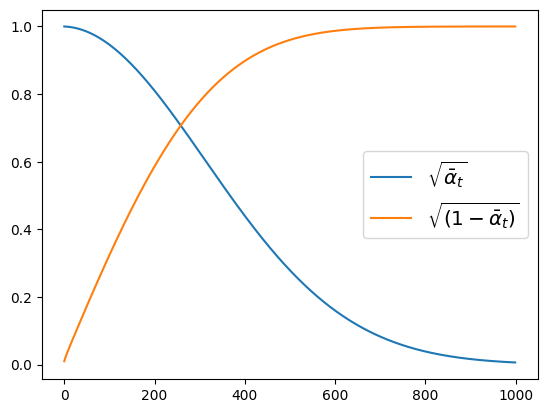

In [373]:
noise_scheduler = DDPMScheduler(num_train_timesteps=1000, clip_sample_range =3)

plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize="x-large")

Синяя линия:
Вес исходного изображения в зашумленной версии
Физический смысл: Насколько "сильно" оригинальное изображение сохраняется на шаге t
Поведение: Убывает от 1 до 0 по мере увеличения t


Оранжевая линия:
Вес шума в зашумленной версии
Физический смысл: Насколько "сильно" шум влияет на изображение на шаге t
Поведение: Возрастает от 0 до 1 по мере увеличения t

## Задание 4 (0.5 балла)

Реализуйте нейронную сеть. В качетсве архитектуры можете взять модель генератора. В процессе экспериментов попробуйте изменять архитектуру модели для улучшения качества сгенерированных объектов (Кстати, как вы будете качество измерять?).

- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Выходной слой.

In [189]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

я тут уже пыталя улучшить, добавил только ембединги для шага зашумления и для класса

In [363]:
class DiffusionGenerator(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super(DiffusionGenerator, self).__init__()


        ### YOUR CODE IS HERE ######,
        total_input = n_inputs + 1  # z + y
        
        self.net = nn.Sequential(
            nn.Linear(total_input, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.BatchNorm1d(100), 
            nn.ReLU(),
            nn.Linear(100, n_outputs),
        )
        
        ### THE END OF YOUR CODE ###
# тут добавим параметр отвечающий за время  генерации шума, потом убрал... наверно надо  добавить в улучшения
    

    def forward(self, z, y):
        zy = torch.cat((z, y), dim=1)
        return self.net(zy)

## Задание 5 (0.5 балла)

Напишите функцию для генерации нового объекта с помощью обученной модели.

In [364]:
def generate_with_diffusion(model, y, latent_dim, scheduler):
    ### YOUR CODE IS HERE ######
    model.eval()
    with torch.no_grad():
        device = next(model.parameters()).device
        x = torch.randn(len(y), latent_dim, device=device)
        y = y.to(device)
        
        timesteps = scheduler.timesteps.to(device)
        
        for t in timesteps:
            noise_pred = model(x, y)
            x = scheduler.step(noise_pred, t, x).prev_sample
    
    X_fake = x.cpu().numpy()
    return X_fake # numpy

## Задание 6 (2 балла)

Напишите класс обучения диффузионной модели и обучите модель, после чего опишите полученные результаты. В качестве подсказки - опирайтесь на семинар по диффузионным моделям. Вы можете изменять некоторые части кода для вашего удобства, но оставляйте в таком случаи комментарии, пожалуйста.

In [193]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

In [194]:
RT=42 # randomstate

In [365]:
def other_agent_score(real_data, fake_data):
    real_labels = np.ones(len(real_data))
    fake_labels = np.zeros(len(fake_data))
    X = np.vstack([real_data, fake_data])
    y = np.hstack([real_labels, fake_labels])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.25,  
        stratify=y,      
        random_state=RT
    )

    lr_model = LogisticRegression(random_state=RT, max_iter=1000)
    lr_model.fit(X_train, y_train)
    lr_pred = lr_model.predict(X_test)
    lr_accuracy = accuracy_score(y_test, lr_pred)

    gb_model = GradientBoostingClassifier(random_state=RT)
    gb_model.fit(X_train, y_train)
    gb_pred = gb_model.predict(X_test)
    gb_accuracy = accuracy_score(y_test, gb_pred)

    return {
        'LR': lr_accuracy,
        'GB': gb_accuracy
    }

In [196]:
noise_scheduler.timesteps

tensor([999, 998, 997, 996, 995, 994, 993, 992, 991, 990, 989, 988, 987, 986,
        985, 984, 983, 982, 981, 980, 979, 978, 977, 976, 975, 974, 973, 972,
        971, 970, 969, 968, 967, 966, 965, 964, 963, 962, 961, 960, 959, 958,
        957, 956, 955, 954, 953, 952, 951, 950, 949, 948, 947, 946, 945, 944,
        943, 942, 941, 940, 939, 938, 937, 936, 935, 934, 933, 932, 931, 930,
        929, 928, 927, 926, 925, 924, 923, 922, 921, 920, 919, 918, 917, 916,
        915, 914, 913, 912, 911, 910, 909, 908, 907, 906, 905, 904, 903, 902,
        901, 900, 899, 898, 897, 896, 895, 894, 893, 892, 891, 890, 889, 888,
        887, 886, 885, 884, 883, 882, 881, 880, 879, 878, 877, 876, 875, 874,
        873, 872, 871, 870, 869, 868, 867, 866, 865, 864, 863, 862, 861, 860,
        859, 858, 857, 856, 855, 854, 853, 852, 851, 850, 849, 848, 847, 846,
        845, 844, 843, 842, 841, 840, 839, 838, 837, 836, 835, 834, 833, 832,
        831, 830, 829, 828, 827, 826, 825, 824, 823, 822, 821, 8

In [366]:
class DiffusionFitter(object):
    def __init__(
        self,
        model,
        batch_size = 32,
        n_epochs = 100,
        latent_dim = 1,
        lr = 0.0001,
        n_critic=5,
    ):

        self.model = model
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.latent_dim = latent_dim
        self.lr = lr
        self.n_critic = n_critic

        self.opt_gen = torch.optim.RMSprop(self.model.parameters(), lr=self.lr)

        self.model.to(DEVICE)

    def fit(self, X, y):

        # numpy to tensor
        X_real = torch.tensor(X, dtype=torch.float, device=DEVICE)
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        # tensor to dataset
        dataset_real = TensorDataset(X_real, y_cond)

        # Turn on training
        self.model.train(True)

        self.loss_history = []

        # Fit
        for epoch in range(self.n_epochs):
            loss_epoch = 0
            for i, (real_batch, cond_batch) in enumerate(
                DataLoader(dataset_real, batch_size=self.batch_size, shuffle=True)
            ):

                ### YOUR CODE IS HERE ######
                noise = torch.randn_like(real_batch)

                timesteps = torch.randint(0, 1000, (real_batch.size(0),), device=DEVICE)
                
                noisy_data = noise_scheduler.add_noise(real_batch, noise, timesteps)
                
                noise_pred = self.model(noisy_data, cond_batch)
                
                loss = F.mse_loss(noise_pred, noise)
                
                self.opt_gen.zero_grad()
                loss.backward()
                self.opt_gen.step()
                
                loss_epoch += loss.item()
                ### THE END OF YOUR CODE ###

            # caiculate and store loss after an epoch

            self.loss_history.append(loss_epoch)

            # Создайте выборку из 1000 объектов из X_train и 1000 сгенерированных объектов
            # И запустите работу фукнции other_agent_score

            ### YOUR CODE IS HERE ######
            if epoch % 5 == 0 or epoch == self.n_epochs - 1:  
                with torch.no_grad():
                    indices = torch.randperm(len(X_real))[:1000]
                    real_sample = X_real[indices].cpu().numpy()
                    real_cond = y_cond[indices].to(DEVICE)
                    
                    fake_sample = generate_with_diffusion(
                        self.model, real_cond, self.latent_dim, noise_scheduler
                    )
                    score = other_agent_score(real_sample, fake_sample)
                    print(f"Epoch {epoch}, Loss: {loss_epoch:.4f}, "
                        f"Scores: LR={score['LR']:.3f}, GB={score['GB']:.3f}")
            ### THE END OF YOUR CODE ###

        # Turn off training
        self.model.train(False)

In [374]:
if model:
    del model

In [368]:
X_train_qt

array([[ 1.94535607e-01,  2.76849744e-01,  7.44221755e-01, -6.75425426e-01, -6.47924060e-01,  6.12440601e-01,  2.67264067e-01, -1.36867734e+00,  5.63602322e-01, -1.65088571e+00],
       [ 1.61493188e+00,  2.09969960e+00,  1.98727407e+00, -2.79218238e+00, -2.77321673e+00,  6.15311882e-01,  1.82011324e+00,  1.18383402e+00,  1.54727610e+00,  8.80213345e-02],
       [ 1.83257283e-01,  3.62549463e-01, -5.75095361e-02, -7.43150070e-03,  3.02370676e-01, -1.36144404e+00,  4.39150246e-01, -4.94519862e-01, -9.17499037e-01,  6.90764008e-01],
       [ 5.33559051e-01,  2.00325518e-01,  5.16027020e-01, -7.57938796e-01, -7.93439663e-01,  4.28972740e-01,  3.48678528e-01,  4.76345739e-01, -1.45260018e+00,  2.00945191e-01],
       [ 2.87149900e-01,  4.77287047e-01,  5.65908911e-02, -1.85828741e-01, -3.10063029e-01,  1.20203125e-02,  7.33025658e-01,  5.60546769e-01,  5.95095130e-01,  1.97226329e-01],
       [ 4.34589565e-01, -3.22418240e-01,  4.43623753e-01, -7.46734433e-01, -7.96885209e-01,  1.08730544e

In [380]:
%%time
latent_dim = 10
# тут вообще что то странное зачем там задавать размерность? не легче хардкорно написать то?
model = DiffusionGenerator(n_inputs=latent_dim,n_outputs=X_train_qt.shape[1])

diffusionFitter = DiffusionFitter(
    model,
    batch_size=64,
    n_epochs=100,
    latent_dim=latent_dim,
    lr=0.0001,
    n_critic=5,
)
diffusionFitter.fit(X_train_qt, y_train)

Epoch 0, Loss: 165.0954, Scores: LR=0.608, GB=0.832
Epoch 5, Loss: 79.8746, Scores: LR=0.532, GB=0.758
Epoch 10, Loss: 78.8440, Scores: LR=0.518, GB=0.756
Epoch 15, Loss: 77.2486, Scores: LR=0.580, GB=0.748
Epoch 20, Loss: 76.3378, Scores: LR=0.512, GB=0.744
Epoch 25, Loss: 74.8168, Scores: LR=0.552, GB=0.740
Epoch 30, Loss: 74.7422, Scores: LR=0.538, GB=0.748
Epoch 35, Loss: 75.2356, Scores: LR=0.542, GB=0.740
Epoch 40, Loss: 72.6091, Scores: LR=0.530, GB=0.762
Epoch 45, Loss: 70.8762, Scores: LR=0.590, GB=0.706
Epoch 50, Loss: 72.8110, Scores: LR=0.560, GB=0.728
Epoch 55, Loss: 73.7858, Scores: LR=0.546, GB=0.720
Epoch 60, Loss: 72.7040, Scores: LR=0.538, GB=0.742
Epoch 65, Loss: 72.9595, Scores: LR=0.530, GB=0.738
Epoch 70, Loss: 71.4548, Scores: LR=0.558, GB=0.734
Epoch 75, Loss: 70.9177, Scores: LR=0.558, GB=0.728
Epoch 80, Loss: 70.4232, Scores: LR=0.562, GB=0.738
Epoch 85, Loss: 70.9747, Scores: LR=0.518, GB=0.736
Epoch 90, Loss: 69.7310, Scores: LR=0.580, GB=0.756
Epoch 95, Los

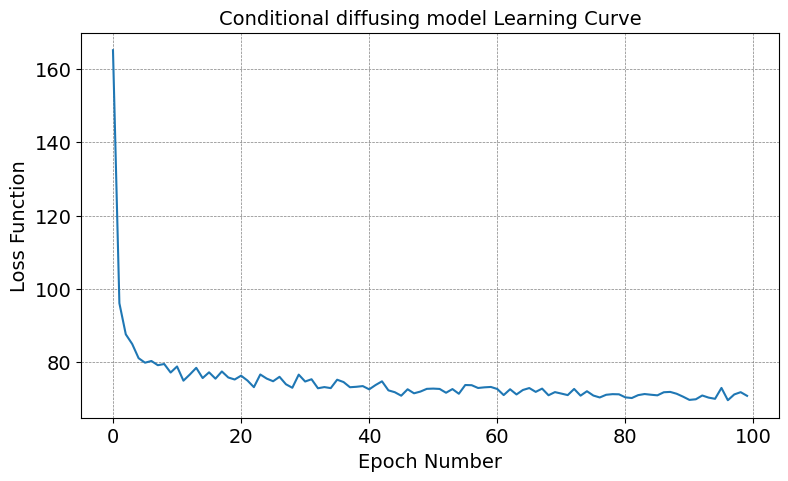

In [ ]:

plt.figure(figsize=(9, 5))
plt.plot(diffusionFitter.loss_history)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("Conditional diffusing model Learning Curve", size=14)
plt.grid( linestyle="--", linewidth=0.5, color="0.5")
plt.show()

## Задание 7 (0.5 балла)
По аналогии с прошлым экспериментом (из ДЗ-2) с GAN моделью сгенерируйте выборку фейковых объектов, равную размеру тестовой выборки, и обучите градиентный бустинг. Обучите модель отличать реальные объекты от фейковых, после чего расчитайте метрики ROC-AUC и accuracy score. Какие получились результаты? Как вы их оцениваете? А в сравнении с сWGAN моделью?

In [ ]:
with torch.no_grad():
    y_test_tensor = torch.tensor(y_test, device=DEVICE).float()
    
    X_fake_test = generate_with_diffusion(
        diffusionFitter.model, 
        y_test_tensor, 
        latent_dim, 
        noise_scheduler
    )

X_combined = np.vstack([X_test_qt, X_fake_test])
y_combined = np.hstack([np.ones(len(X_test_qt)), np.zeros(len(X_fake_test))])


X_train_comb, X_test_comb, y_train_comb, y_test_comb = train_test_split(
    X_combined, y_combined, test_size=0.3, random_state=33, stratify=y_combined
)

gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=33
)
gb.fit(X_train_comb, y_train_comb)
y_pred = gb.predict(X_test_comb)
y_pred_proba = gb.predict_proba(X_test_comb)[:, 1]
auc = roc_auc_score(y_test_comb, y_pred_proba)
accuracy = accuracy_score(y_test_comb, y_pred)
print(f"ROC-AUC: {auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")



ROC-AUC: 0.8470
Accuracy: 0.7650


что то я делаю не так =( почему то  большой такой рокаук
догадываюсь что в шедулере... там добавил клипинг без него фейковые были от -1 до 1 в распределении

Real - mean: [ 0.00971839 -0.00635866  0.00498078 -0.01384449 -0.0117012 ]
Fake - mean: [-0.01584618 -0.01757487  0.02255813  0.03325509  0.0347972 ]
Real - std: [0.99389808 1.06369321 0.9960409  0.98900666 0.99104341]
Fake - std: [1.2214739 1.2094735 1.241816  1.3018615 1.2778206]


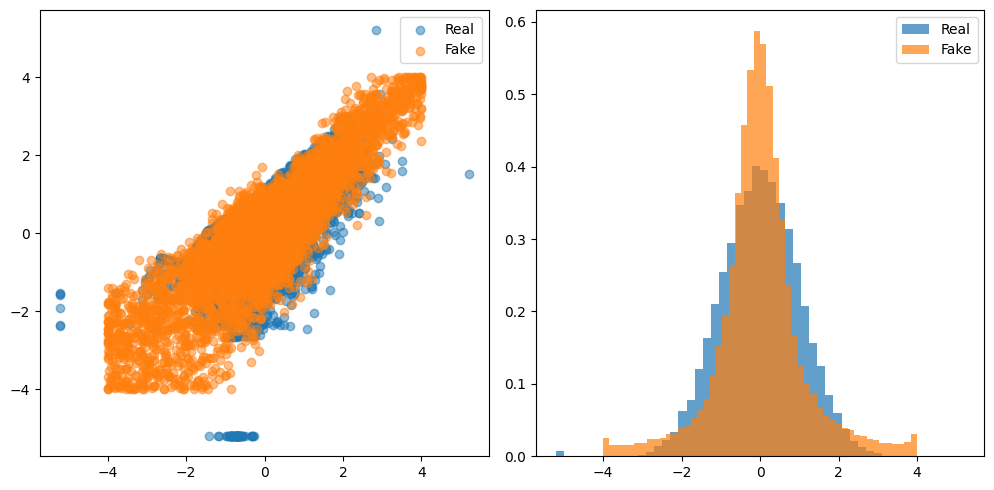

In [372]:
# Проверим статистики
print(f"Real - mean: {X_test_qt.mean(axis=0)[:5]}") 
print(f"Fake - mean: {X_fake_test.mean(axis=0)[:5]}")
print(f"Real - std: {X_test_qt.std(axis=0)[:5]}")
print(f"Fake - std: {X_fake_test.std(axis=0)[:5]}")


plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.scatter(X_test_qt[:, 0], X_test_qt[:, 1], alpha=0.5, label='Real')
plt.scatter(X_fake_test[:, 0], X_fake_test[:, 1], alpha=0.5, label='Fake')
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(X_test_qt.flatten(), bins=50, alpha=0.7, label='Real', density=True)
plt.hist(X_fake_test.flatten(), bins=50, alpha=0.7, label='Fake', density=True)
plt.legend()

plt.tight_layout()
plt.show()

# Потоки (4 балла)

## Задание 8 (1.5 балла)

Диффузия показала себя как достойный конкурент GAN модели. Так как данных не много, обучали не долго, задача не сложная - отличия от GAN не так заметны, но все равно достойные.

Для Diffusion получили ROC AUC около 0.73 (меньше лучше). Попробуем обучить RealNVP для решения этой задачи.

**Дополните базовый класс для нормализационного необходимым.**

<center><img src="img/mem1.jpg" width="500"></center>

<center><img src="img/mem2.jpg" width="500"></center>

In [121]:
trainloader = torch.utils.data.DataLoader(X_train_qt, batch_size=64, shuffle=True)

In [122]:
# Main class for NormFlow
class NormalizingFlow(nn.Module):

    def __init__(self, layers, prior):
        super(NormalizingFlow, self).__init__()

        # your code below
        self.layers = nn.ModuleList(layers)
        self.prior = prior

    def log_prob(self, x):
        log_likelihood = None

        for layer in self.layers:
            x, change = layer.f(x)
            if log_likelihood is not None:
                log_likelihood = log_likelihood + change
            else:
                log_likelihood = change

        log_likelihood = log_likelihood + self.prior.log_prob(x)
        return log_likelihood.mean()

    def sample(self, num_samples):
        x = self.prior.sample((num_samples, ))

        for layer in self.layers[::-1]:
            x = layer.g(x)

        return x

## Задание 9 (2 балла)

Реализуйте нейронную сеть RealNVP. Возьмите для прямого и обратного преобразования нейронную сеть (функцию) со следующими параметрами:

- Полносвязный слой со 100 нейронами;
- ReLU функцию активации;
- Выходной слой.

In [123]:
import torch.nn as nn

class RealNVP(nn.Module):
    def __init__(self, var_size, mask, hidden=100):
        super(RealNVP, self).__init__()
        self.mask = mask  # вам это может не понадобиться. Восприниматйте как подсказку
        self.var_size = var_size

        self.nn_t = nn.Sequential(
            nn.Linear(var_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, var_size)
        )
        self.nn_s =nn.Sequential(
            nn.Linear(var_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, var_size)
        )

    def f(self, x):
        t = self.nn_t( x * self.mask)
        s = self.nn_s(x * self.mask)

        new_x = x * self.mask + (1 - self.mask) * (x * torch.exp(s) + t)

        log_det = ((1 - self.mask) * s).sum(dim=1)
        return new_x, log_det

    def g(self, x):
        t = self.nn_t( x * self.mask)
        s = self.nn_s(x * self.mask)

        new_x = x * self.mask +  (1 - self.mask) * ((x - t) * torch.exp(-s))

        return new_x

In [124]:
def train_nf(tr_dataloader, nf, opt, num_epochs):
    nf.train()
    loss_trace = []

    iter_i = 0

    for epoch_i in range(num_epochs):
        print(f'Epoch {epoch_i + 1}')
        for batch in tr_dataloader:

            x = batch.float()

            opt.zero_grad()

            loss = -nf.log_prob(x)
            loss.backward()

            opt.step()

            loss_trace.append((iter_i, loss.item()))

            iter_i += 1

In [125]:
prior = torch.distributions.MultivariateNormal(torch.zeros(10), torch.eye(10))

layers = []
for i in range(4):
    layers.append(RealNVP(var_size=10, mask=((torch.arange(10) + i) % 2)))

nf = NormalizingFlow(layers=layers,
                    prior=prior)

opt = torch.optim.Adam(nf.parameters(), lr=1e-3)

In [126]:
train_nf(trainloader, nf, opt, num_epochs=10)

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10


## Задание 10 (0.5 балла)

По аналогии с прошлым экспериментом с диффузией сгенерируйте выборку фейковых объектов, равную размеру тестовой выборки, и обучите градиентный бустинг. Обучите модель отличать реальные объекты от фейковых, после чего расчитайте метрики ROC-AUC и accuracy score. Какие получились результаты? Как вы их оцениваете? А в сравнении с остальными моделями?

In [ ]:
def create_masks(input_dim, num_layers):
    masks = []
    for i in range(num_layers):
        if i % 2 == 0:
            mask = torch.tensor([1 if j % 2 == 0 else 0 for j in range(input_dim)], dtype=torch.float32)
        else:
            mask = torch.tensor([0 if j % 2 == 0 else 1 for j in range(input_dim)], dtype=torch.float32)
        masks.append(mask)
    return masks

In [128]:
with torch.no_grad():
    nf.eval()
    fake_samples_nf = nf.sample(len(X_test_qt)).numpy()

X_real_test_nf = X_test_qt.values if hasattr(X_test_qt, 'values') else X_test_qt
y_real_test_nf = np.ones(len(X_real_test_nf))  #реал

X_fake_test_nf = fake_samples_nf
y_fake_test_nf = np.zeros(len(X_fake_test_nf))  # фейк

X_combined_nf = np.vstack([X_real_test_nf, X_fake_test_nf])
y_combined_nf = np.hstack([y_real_test_nf, y_fake_test_nf])

indices_nf = np.random.permutation(len(X_combined_nf))
X_combined_nf = X_combined_nf[indices_nf]
y_combined_nf = y_combined_nf[indices_nf]


gb_classifier_nf = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42
)
gb_classifier_nf.fit(X_combined_nf, y_combined_nf)


y_pred_proba_nf = gb_classifier_nf.predict_proba(X_combined_nf)[:, 1]
y_pred_nf = gb_classifier_nf.predict(X_combined_nf)

roc_auc_nf = roc_auc_score(y_combined_nf, y_pred_proba_nf)
accuracy_nf = accuracy_score(y_combined_nf, y_pred_nf)

print(f"ROC-AUC: {roc_auc_nf:.4f}")
print(f"Accuracy: {accuracy_nf:.4f}")


ROC-AUC: 0.6956
Accuracy: 0.6296


в принципе получились неплохо но рядом с другими архитектурами

# Улучшения (1+ балл)

Попробуйте настроить параметры обучения какой-нибудь модели или еще как-нибудь их улучшить, чтобы получить как можно меньший ROC AUC. Что получилось? Какая модель лучше?

Ставим 0.1 балл за каждую сотую скора сверх (сниз) ROC-AUC=0.65 невключительно. Т.е. за 0.65 получаете 0, за 0.649 -- 0.1, 0.639 -- 0.2, 0.609 -- 0.5, 0.559 -- 1

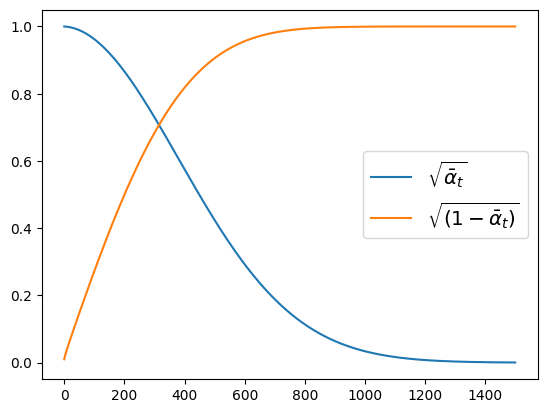

In [760]:
thebest_noise_scheduler = DDPMScheduler(
    num_train_timesteps=1500,
    # beta_schedule="squaredcos_cap_v2",
    # prediction_type="epsilon",
    clip_sample=False
    # sample_max_value=3,
    # clip_sample_range=3       #смотрим наши р,аспределения

)
plt.plot(thebest_noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - thebest_noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize="x-large")


In [384]:
X_train_qt

array([[ 1.94535607e-01,  2.76849744e-01,  7.44221755e-01, -6.75425426e-01, -6.47924060e-01,  6.12440601e-01,  2.67264067e-01, -1.36867734e+00,  5.63602322e-01, -1.65088571e+00],
       [ 1.61493188e+00,  2.09969960e+00,  1.98727407e+00, -2.79218238e+00, -2.77321673e+00,  6.15311882e-01,  1.82011324e+00,  1.18383402e+00,  1.54727610e+00,  8.80213345e-02],
       [ 1.83257283e-01,  3.62549463e-01, -5.75095361e-02, -7.43150070e-03,  3.02370676e-01, -1.36144404e+00,  4.39150246e-01, -4.94519862e-01, -9.17499037e-01,  6.90764008e-01],
       [ 5.33559051e-01,  2.00325518e-01,  5.16027020e-01, -7.57938796e-01, -7.93439663e-01,  4.28972740e-01,  3.48678528e-01,  4.76345739e-01, -1.45260018e+00,  2.00945191e-01],
       [ 2.87149900e-01,  4.77287047e-01,  5.65908911e-02, -1.85828741e-01, -3.10063029e-01,  1.20203125e-02,  7.33025658e-01,  5.60546769e-01,  5.95095130e-01,  1.97226329e-01],
       [ 4.34589565e-01, -3.22418240e-01,  4.43623753e-01, -7.46734433e-01, -7.96885209e-01,  1.08730544e

In [422]:
X_test_qt

array([[-0.11461119, -2.00070042, -0.39688554,  0.38609684,  0.16816426,  0.9619089 ,  0.20840411, -1.17345207, -0.53146705,  0.81704396],
       [ 2.17904644,  1.89122017,  2.52826086, -2.31763288, -2.29648727,  1.00372808,  2.13196511,  1.05867676,  1.46452234,  1.92086489],
       [-1.84307066, -0.97843198, -1.25793066,  2.01368702,  1.77878574, -0.46821189, -2.13698575,  0.12448622,  0.12894972,  0.03489706],
       [-1.20990038, -1.40673072, -1.13946558,  1.33542459,  1.219496  , -0.34853929, -2.13418414, -1.79168975,  0.74509652, -0.7942412 ],
       [ 0.65250732,  0.70217603,  0.88053201, -1.2290127 , -1.29024571,  1.18870102,  0.35451056,  0.64983   , -0.46246373,  0.89567273],
       [-0.05448405, -0.21117129,  0.12844655,  0.00586055, -0.14534874, -0.70116578, -0.06565758, -0.73376312, -0.14390521, -0.34920117],
       [-0.83256738, -5.19933758, -2.06689388,  1.88270366,  1.69231052, -5.19933758, -5.19933758,  0.22308061,  0.81695258,  0.30127857],
       [ 0.57010079,  0.820

In [706]:
class best_DiffusionGenerator(nn.Module):
    def __init__(self, n_inputs, n_outputs, num_classes=2, class_emb_size=2, time_embed_dim=2):
        super(best_DiffusionGenerator, self).__init__()
        
        self.class_emb = nn.Embedding(num_classes, class_emb_size)
        self.time_embed = nn.Linear(1, time_embed_dim)
        
        total_input = n_inputs + time_embed_dim + class_emb_size
        bs=512

       
        self.net = nn.Sequential(
            nn.Linear(total_input, bs),    
            nn.BatchNorm1d(bs),
            nn.ReLU(),
            
            nn.Linear(bs, bs),             
            nn.BatchNorm1d(bs),
            nn.ReLU(),
            
            nn.Linear(bs, bs//2),             
            nn.BatchNorm1d(bs//2),
            nn.ReLU(),
            nn.Linear(bs//2, bs//2),             
            nn.BatchNorm1d(bs//2),
            nn.ReLU(),
            
            nn.Linear(bs//2, bs//16),             
            # nn.BatchNorm1d(bs//2),
            nn.ReLU(),
            
            nn.Linear(bs//16, n_outputs),
        )

    def forward(self, z, t, y):
        t = t.float().unsqueeze(-1)
        t_embed = self.time_embed(t)
        class_emb = self.class_emb(y.long().squeeze(1))
        zty = torch.cat((z, t_embed, class_emb), dim=1)
        return self.net(zty)

In [483]:
def best_generate_with_diffusion(model, y, latent_dim, scheduler):
    ### YOUR CODE IS HERE ######
    X_fake = torch.randn(len(y), latent_dim).to(DEVICE)
    model.eval()
    with torch.no_grad():
            for t in scheduler.timesteps:
                t_batch = torch.full((len(y),), t, device=DEVICE, dtype=torch.long)
                noise_pred = model(X_fake, t_batch, y)
                X_fake = scheduler.step(noise_pred, t, X_fake).prev_sample
        ### THE END OF YOUR CODE ###
    return X_fake.cpu().numpy() # numpy

In [761]:
class best_DiffusionFitter(object):
    def __init__(
        self,
        model,
        batch_size=32,
        n_epochs=100,
        latent_dim=10,
        lr=0.00001,
    ):
        self.model = model
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.latent_dim = latent_dim
        self.lr = lr

      
        self.opt_gen = torch.optim.AdamW(self.model.parameters(), lr=self.lr, weight_decay=1e-2)
        
        self.model.to(DEVICE)

    def fit(self, X, y):
        X_real = torch.tensor(X, dtype=torch.float, device=DEVICE)
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)
        dataset_real = TensorDataset(X_real, y_cond)

        self.model.train(True)
        self.loss_history = []
        


        for epoch in range(self.n_epochs):
            loss_epoch = 0
            for i, (real_batch, cond_batch) in enumerate(
                DataLoader(dataset_real, batch_size=self.batch_size, shuffle=True)
            ):
                ### YOUR CODE IS HERE ######
                noise = torch.randn_like(real_batch)
                timesteps = torch.randint(0, 1500, (real_batch.size(0),), device=DEVICE).long()
                
                noisy_data = thebest_noise_scheduler.add_noise(real_batch, noise, timesteps)
                
                noise_pred = self.model(noisy_data, timesteps, cond_batch)
                
                loss = F.mse_loss(noise_pred, noise)
                
                self.opt_gen.zero_grad()
                loss.backward()
                
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                
                self.opt_gen.step()
                
                loss_epoch += loss.item()
                ### THE END OF YOUR CODE ###

            self.loss_history.append(loss_epoch)
            if epoch > 0 and epoch % 50 == 0:
                for param_group in self.opt_gen.param_groups:
                    param_group['lr'] *= 0.8  
                    print(f"lr {param_group['lr']}")
            if epoch % 5 == 0 or epoch == self.n_epochs - 1:  
                with torch.no_grad():
                    indices = torch.randperm(len(X_real))[:1000]
                    real_sample = X_real[indices].cpu().numpy()
                    real_cond = y_cond[indices].to(DEVICE)
                    
                    fake_sample = best_generate_with_diffusion(
                        self.model, real_cond, self.latent_dim, thebest_noise_scheduler
                    )
                    score = other_agent_score(real_sample, fake_sample)
                    
                    print(f"Epoch {epoch}, Loss: {loss_epoch:.4f}, "
                          f"Scores: LR={score['LR']:.3f}, GB={score['GB']:.3f}")

        self.model.train(False)


In [762]:
if best_model:
    del best_model

In [763]:
%%time
latent_dim = 10
# тут вообще что то странное зачем там задавать размерность? не легче хардкорно написать то?
best_model = best_DiffusionGenerator(n_inputs=latent_dim,n_outputs=X_train_qt.shape[1])

diffusionFitter2 = best_DiffusionFitter(
    best_model,
    batch_size=256,
    n_epochs=1000,
    latent_dim=latent_dim,
    lr=0.001,
)

diffusionFitter2.fit(X_train_qt, y_train)

Epoch 0, Loss: 28.7933, Scores: LR=1.000, GB=0.996
Epoch 5, Loss: 9.7632, Scores: LR=0.850, GB=0.890
Epoch 10, Loss: 8.9367, Scores: LR=0.846, GB=0.868
Epoch 15, Loss: 8.4212, Scores: LR=0.674, GB=0.774
Epoch 20, Loss: 8.3224, Scores: LR=0.772, GB=0.790
Epoch 25, Loss: 7.7147, Scores: LR=0.806, GB=0.810
Epoch 30, Loss: 7.5780, Scores: LR=0.786, GB=0.770
Epoch 35, Loss: 7.5830, Scores: LR=0.806, GB=0.830
Epoch 40, Loss: 7.2598, Scores: LR=0.766, GB=0.772
Epoch 45, Loss: 7.4674, Scores: LR=0.796, GB=0.814
lr 0.0008
Epoch 50, Loss: 7.1334, Scores: LR=0.674, GB=0.684
Epoch 55, Loss: 6.7706, Scores: LR=0.696, GB=0.728
Epoch 60, Loss: 6.6570, Scores: LR=0.568, GB=0.604
Epoch 65, Loss: 6.8043, Scores: LR=0.644, GB=0.660
Epoch 70, Loss: 6.6301, Scores: LR=0.800, GB=0.750
Epoch 75, Loss: 6.7249, Scores: LR=0.662, GB=0.664
Epoch 80, Loss: 6.8110, Scores: LR=0.686, GB=0.704
Epoch 85, Loss: 6.6882, Scores: LR=0.658, GB=0.664
Epoch 90, Loss: 6.6512, Scores: LR=0.660, GB=0.606
Epoch 95, Loss: 6.4760

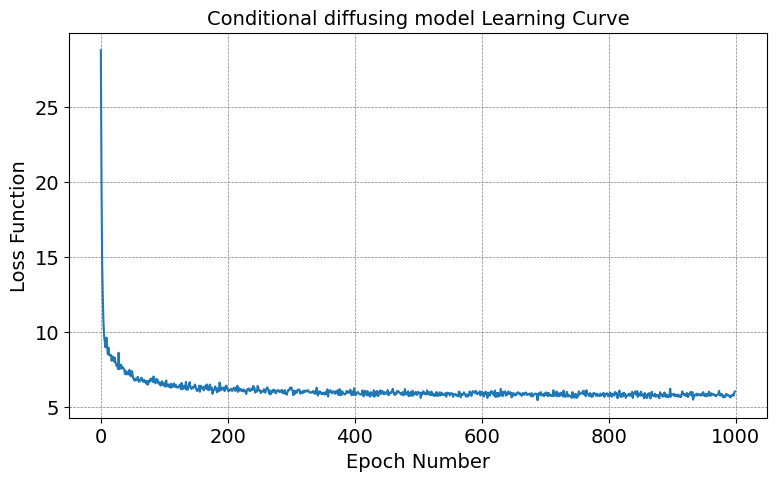

In [764]:
# diffusion learning curve
plt.figure(figsize=(9, 5))
plt.plot(diffusionFitter2.loss_history)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("Conditional diffusing model Learning Curve", size=14)
plt.grid( linestyle="--", linewidth=0.5, color="0.5")
plt.show()

In [832]:
# Сгенерируем фейковые данные размером с тестовую выборку
latent_dim=10
with torch.no_grad():
    # Берем условия из тестовой выборки
    y_test_tensor = torch.tensor(y_test, device=DEVICE).float()
    
    # Генерируем фейковые данные
    X_fake_test = best_generate_with_diffusion(
        diffusionFitter2.model, 
        y_test_tensor, 
        latent_dim, 
        thebest_noise_scheduler
    )
# Создаем объединенный датасет для классификации
X_combined = np.vstack([X_test_qt, X_fake_test])
y_combined = np.hstack([np.ones(len(X_test_qt)), np.zeros(len(X_fake_test))])
# Разделяем на train/test


X_train_comb, X_test_comb, y_train_comb, y_test_comb = train_test_split(
    X_combined, y_combined, test_size=0.3, random_state=33, stratify=y_combined
)

gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=5
)
gb.fit(X_train_comb, y_train_comb)
y_pred = gb.predict(X_test_comb)
y_pred_proba = gb.predict_proba(X_test_comb)[:, 1]
auc = roc_auc_score(y_test_comb, y_pred_proba)
accuracy = accuracy_score(y_test_comb, y_pred)
print(f"ROC-AUC: {auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")



ROC-AUC: 0.5561
Accuracy: 0.5428


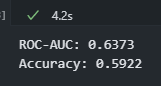
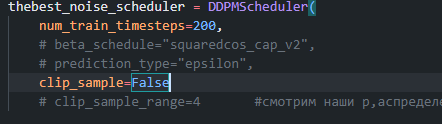

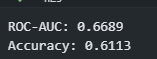
clip_sample_range=4 

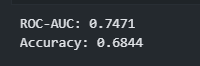
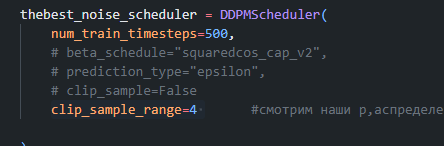

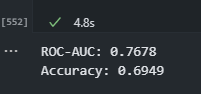
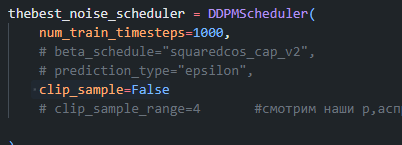

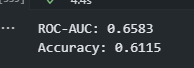
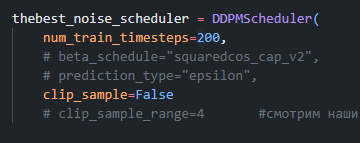

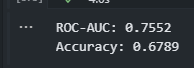
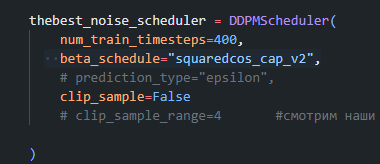

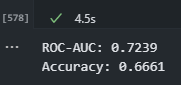
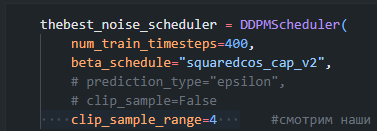

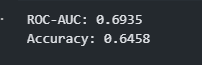
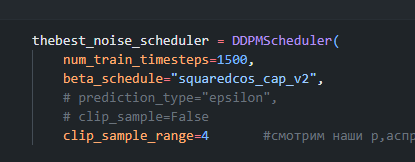

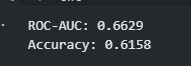
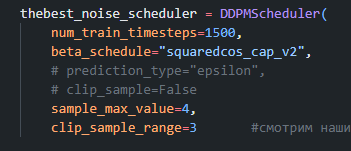

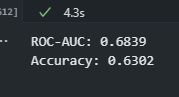
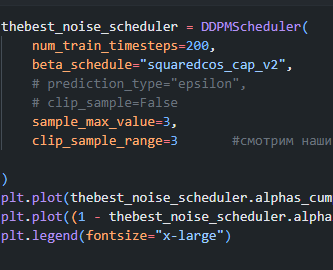
бачт 256

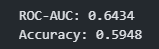
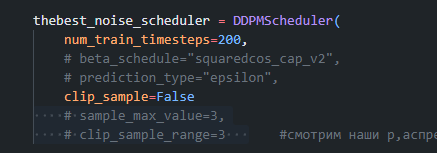

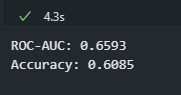
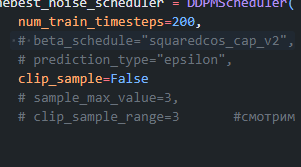
нейронов 256

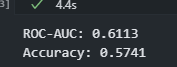
динамическеий lr

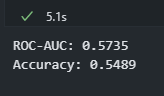
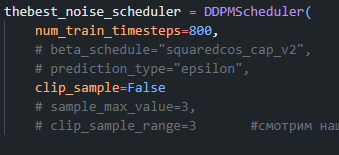
и динамический лр и 1000 эпох

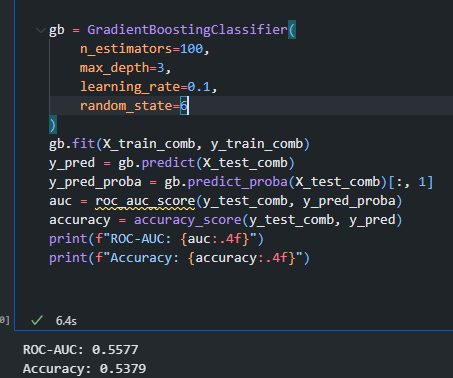

# (*) Аналитика (1 балл)

***Убедительно* подвтердите или опровергните гипотезу "Синтетические данные НЕ помогают лучше классифицировать частицы из исходного датасета."**

Здесь от вас ожидается что-то в духе аналитической записки. Приветствуются графики и прочие "умные вещи". На максимальный балл это весьма объемное задание.